# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [ ]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [9]:
import pandas as pd

# The base URL for the repository's data files
base_url = "https://huggingface.co/datasets/SetFit/20_newsgroups/resolve/main"

# Constructing the full paths
splits = {
    'train': f"{base_url}/train.jsonl",
    'test': f"{base_url}/test.jsonl"
}

# Loading the training split into a dataframe
df = pd.read_json(splits['train'], lines=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
sci.med                     594
rec.autos                   594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [10]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [11]:
# Choosing 3 distinct categories for meaningful analysis
my_categories = ["sci.space", "talk.politics.guns", "alt.atheism"]

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())

Selected categories: ['sci.space', 'talk.politics.guns', 'alt.atheism']
Filtered dataset size: 1619

Distribution:
label_text
sci.space             593
talk.politics.guns    546
alt.atheism           480
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

*[Write your answer here - minimum 3 sentences]*

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [13]:
import re
import string

def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()

    # Remove emails
    text = re.sub(r'\S+@\S+', '', text)

    # Remove URLs
    text = re.sub(r'https?://\S+|www\.\S+', '', text)

    # Remove numbers
    text = re.sub(r'\d+', '', text)

    # Remove punctuation
    # This creates a translation table that maps every punctuation character to None
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Remove extra whitespace
    # split() without arguments handles all whitespace (newlines, tabs, multiple spaces)
    text = " ".join(text.split()).strip()

    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [17]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# Ensure NLTK resources are downloaded
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True) # Added to address the LookupError

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    """
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = text.lower()
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Step 2: Tokenize
    tokens = word_tokenize(text)

    # Step 3: Remove stop words
    tokens = [w for w in tokens if w not in stop_words]

    # Step 4: Lemmatize
    # Converts words to their base dictionary form (e.g., 'cats' -> 'cat')
    tokens = [lemmatizer.lemmatize(w) for w in tokens]

    # Step 5: Remove short words (< 3 chars)
    tokens = [w for w in tokens if len(w) >= 3]

    # Step 6: Join back to string
    return " ".join(tokens)

# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [18]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
article tom baker understanding expected error basically known bug warning system software thing checked dont right value yet arent set till launch suchlike rather fix code possibly introduce new bug tell crew see warning liftoff ignore


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

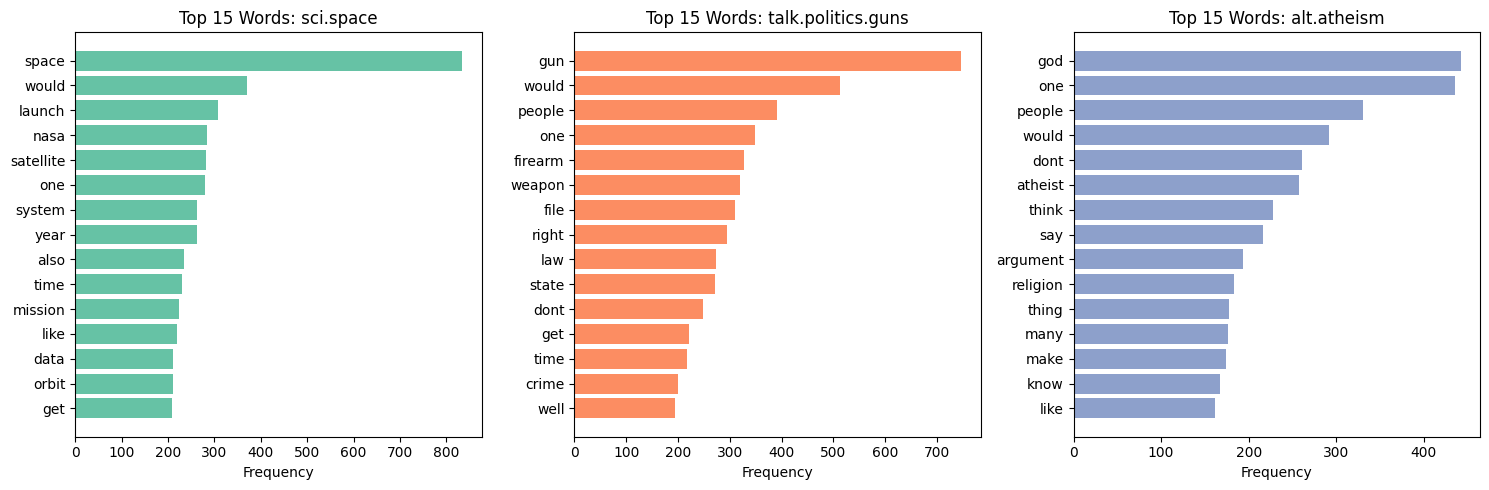

In [19]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)

    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (___):*
- Unique words: ...
-

*Category 2 (___):*
- Unique words: ...
-

*Category 3 (___):*
- Unique words: ...
-

*Shared words and explanation:*
...

*Topic guessing analysis:*
...

### C.2 Word Clouds

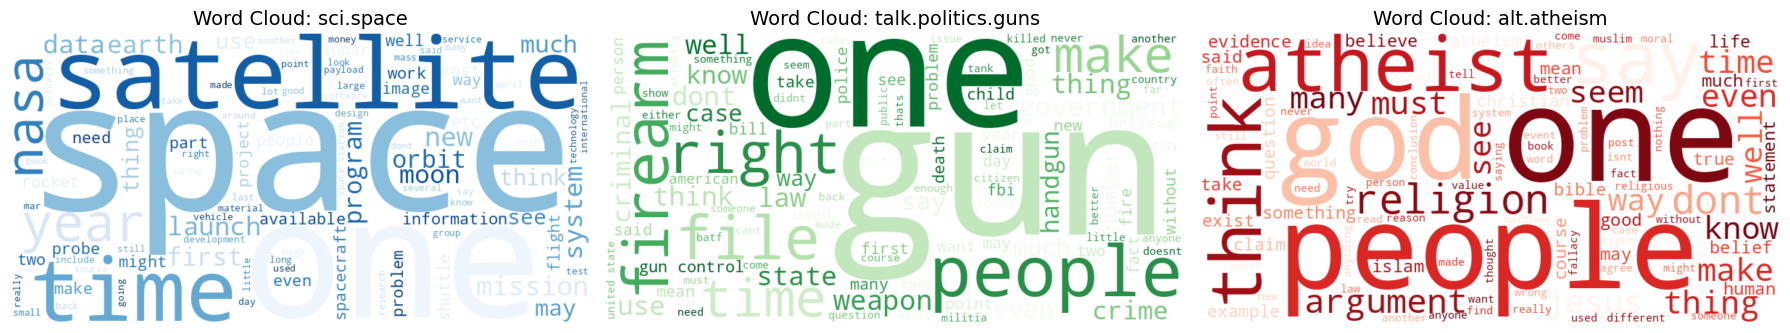

In [20]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)

    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)

    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**.

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

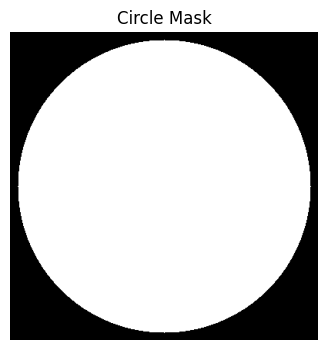

In [21]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.zeros((size, size), dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 255
    return mask

circle_mask = create_circle_mask(400)

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

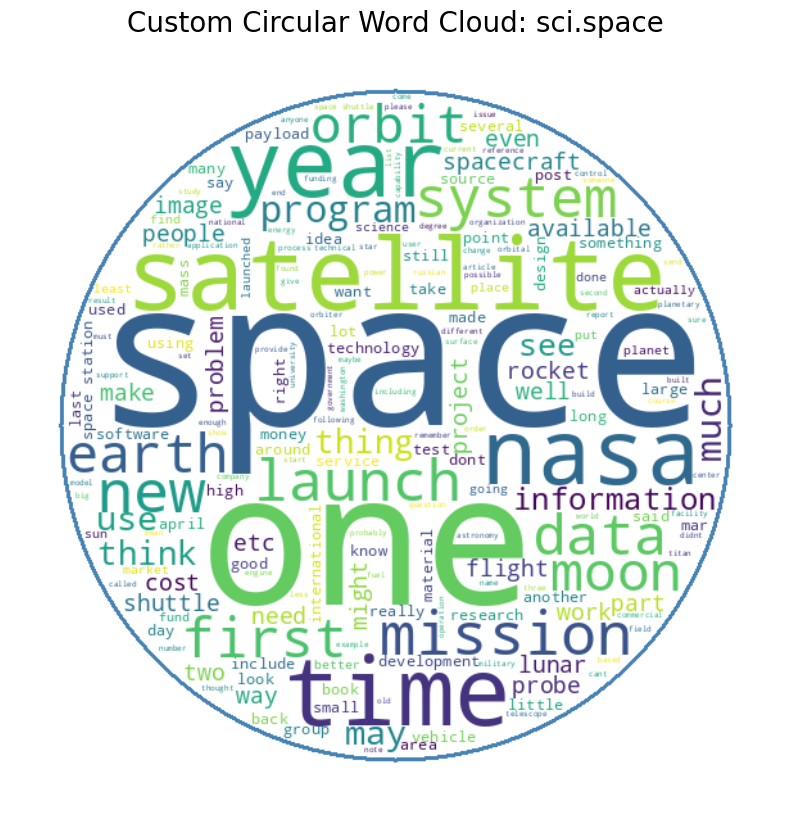

In [22]:
import numpy as np
from PIL import Image
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Choose ONE category
selected_category = "sci.space"

# 2. Get and combine texts
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# 3. Create a Custom Mask (Generating a Circle)
x, y = np.ogrid[:600, :600]
# This formula defines a circle: (x-center)^2 + (y-center)^2 > radius^2
mask = (x - 300) ** 2 + (y - 300) ** 2 > 260 ** 2
mask = 255 * mask.astype(int) # WordCloud needs 255 for "masked out" areas

# 4. Create the word cloud
wordcloud_masked = WordCloud(
    background_color='white',
    mask=mask,
    contour_width=2,
    contour_color='steelblue',
    colormap='viridis',
    max_words=200
).generate(text_combined)

# 5. Display
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Circular Word Cloud: {selected_category}', fontsize=20)
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation

In [23]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

# 1. Initialize the CountVectorizer with the specified parameters
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# 2. Fit and transform on your cleaned texts
# Assuming your cleaned column is named 'text_clean' from the previous steps
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

# 3. Print results
print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1619, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['able' 'accept' 'acceptable' 'access' 'accident' 'according' 'account'
 'act' 'action' 'activity' 'actually' 'add' 'addition' 'address'
 'aerospace' 'age' 'agency' 'agent' 'ago' 'agree']


### Exercise D.2: Document Similarity with BoW

In [25]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# 1. Compute similarity matrix
# cosine_similarity works directly on the BoW sparse matrix
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")

# 2. Find the 2 most similar documents
# We need to ignore the diagonal (self-similarity is always 1.0)
sim_matrix_no_diag = similarity_matrix.copy()
np.fill_diagonal(sim_matrix_no_diag, -1)  # Set diagonal to -1 so it's not picked as max

# Get the index of the maximum similarity value
flat_idx_max = np.argmax(sim_matrix_no_diag)
idx1_sim, idx2_sim = np.unravel_index(flat_idx_max, similarity_matrix.shape)

# 3. Find the 2 most different documents
# Get the index of the minimum similarity value
flat_idx_min = np.argmin(similarity_matrix)
idx1_diff, idx2_diff = np.unravel_index(flat_idx_min, similarity_matrix.shape)

# Results
print(f"\n--- Most Similar Documents (Similarity: {similarity_matrix[idx1_sim, idx2_sim]:.4f}) ---")
print(f"Doc {idx1_sim} ({df_filtered.iloc[idx1_sim]['label_text']}): {df_filtered.iloc[idx1_sim]['text'][:150]}...")
print(f"Doc {idx2_sim} ({df_filtered.iloc[idx2_sim]['label_text']}): {df_filtered.iloc[idx2_sim]['text'][:150]}...")

print(f"\n--- Most Different Documents (Similarity: {similarity_matrix[idx1_diff, idx2_diff]:.4f}) ---")
print(f"Doc {idx1_diff} ({df_filtered.iloc[idx1_diff]['label_text']}): {df_filtered.iloc[idx1_diff]['text'][:150]}...")
print(f"Doc {idx2_diff} ({df_filtered.iloc[idx2_diff]['label_text']}): {df_filtered.iloc[idx2_diff]['text'][:150]}...")

Similarity matrix shape: (1619, 1619)

--- Most Similar Documents (Similarity: 1.0000) ---
Doc 656 (sci.space): Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the questio...
Doc 690 (sci.space): Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the questio...

--- Most Different Documents (Similarity: 0.0000) ---
Doc 0 (sci.space): From article <C5owCB.n3p@world.std.com>, by tombaker@world.std.com (Tom A Baker):


My understanding is that the 'expected errors' are basically
known...
Doc 6 (sci.space): Pat sez;

Yeah, but a windscreen cut down most of it.  Canopies ended it completely.

Of course, the environment in space continues to suck :-)

-Tomm...


In [26]:
import numpy as np

# 1. Create a copy to avoid modifying the original matrix
sim_search_matrix = similarity_matrix.copy()

# 2. Fill the diagonal with -1 so a document isn't its own "most similar" match
np.fill_diagonal(sim_search_matrix, -1)

# 3. Find the index of the highest similarity score
# unravel_index converts the flat index of the max value into (row, col) coordinates
flat_idx = np.argmax(sim_search_matrix)
idx1, idx2 = np.unravel_index(flat_idx, sim_search_matrix.shape)

# 4. Assign results
most_similar_idx = (idx1, idx2)
most_similar_score = sim_search_matrix[idx1, idx2]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score:.4f}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

# Optional: Peek at the content to see why they match
print(f"\nDoc {idx1} snippet: {df_filtered.iloc[idx1]['text_clean'][:100]}...")
print(f"Doc {idx2} snippet: {df_filtered.iloc[idx2]['text_clean'][:100]}...")

Most similar documents: (np.int64(656), np.int64(690))
Similarity score: 1.0000

Document 1 category: sci.space
Document 2 category: sci.space

Doc 656 snippet: someone please remind said well known quotation sitting atop rocket awaiting liftoff afterwards answ...
Doc 690 snippet: someone please remind said well known quotation sitting atop rocket awaiting liftoff afterwards answ...


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [27]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the question what he had been thinking about, said (approximately) "half a
million components, each has to work perfectly, each supplied by the lowest
bidder....


Document 2 (first 300 chars):
Can someone please remind me who said a well known quotation? 

He was sitting atop a rocket awaiting liftoff and afterwards, in answer to
the question what he had been thinking about, said (approximately) "half a
million components, each has to work perfectly, each supplied by the lowest
bidder....


**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: ...

2. What makes them similar: ...

3. Is BoW meaningful here: ...

---

## Part E: TF-IDF Representation

In [28]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [29]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

# 1. Initialize the TfidfVectorizer with the specified parameters
tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# 2. Fit and transform the cleaned texts
# This creates the sparse TF-IDF matrix
tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text_clean'])

# 3. Print the results
print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")
print(f"Vocabulary size: {len(tfidf_vectorizer_full.get_feature_names_out())}")

TF-IDF Matrix shape: (1619, 1000)
Vocabulary size: 1000


In [31]:
import numpy as np

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # 1. Get indices of documents in this category
    category_indices = df_filtered[df_filtered['label_text'] == category].index

    # 2. Get their TF-IDF vectors from the full matrix
    category_tfidf = tfidf_matrix_full[category_indices]

    # 3. Compute mean TF-IDF for each word across these documents
    # Result is a 1x1000 matrix; we use .A1 to flatten it to a 1D array
    mean_tfidf = category_tfidf.mean(axis=0).A1

    # 4. Get feature names (the words)
    feature_names = tfidf_vectorizer_full.get_feature_names_out()

    # 5. Get indices of the top n scores
    top_indices = mean_tfidf.argsort()[-n:][::-1]

    # Return list of (word, score) tuples
    return [(feature_names[i], round(mean_tfidf[i], 4)) for i in top_indices]

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    # Formatting the output for readability
    for word, score in top_words:
        print(f"  - {word}: {score}")


Top TF-IDF words for 'sci.space':
  - space: 0.0635
  - would: 0.0375
  - like: 0.0282
  - one: 0.0264
  - nasa: 0.0247
  - orbit: 0.0244
  - launch: 0.0244
  - get: 0.0226
  - year: 0.0223
  - moon: 0.0213

Top TF-IDF words for 'talk.politics.guns':
  - gun: 0.0654
  - would: 0.0467
  - people: 0.0368
  - weapon: 0.0357
  - right: 0.0322
  - dont: 0.0313
  - one: 0.0288
  - law: 0.0269
  - get: 0.026
  - firearm: 0.0255

Top TF-IDF words for 'alt.atheism':
  - god: 0.0556
  - one: 0.0381
  - dont: 0.0351
  - people: 0.0328
  - think: 0.0327
  - would: 0.0303
  - religion: 0.0293
  - say: 0.0289
  - atheist: 0.0281
  - could: 0.0254


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts: ...

2. Words in counts but not TF-IDF: ...

3. Which method is better and why: ...

---

## Part F: N-grams and Next Word Prediction

In [32]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [33]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [34]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
# 2. Fit the bigram vectorizer
# 3. Find most common bigrams

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()

    # YOUR CODE HERE
    top_bigrams = []  # Get top 15 bigrams

    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams[:15]:
        print(f"  {bigram}: {count}")


Top bigrams for 'sci.space':

Top bigrams for 'talk.politics.guns':

Top bigrams for 'alt.atheism':


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [35]:
from collections import defaultdict

class SimpleNextWordPredictor:
    def __init__(self):
        # Using defaultdict(int) makes counting much cleaner
        self.bigram_counts = defaultdict(lambda: defaultdict(int))
        self.unigram_counts = defaultdict(int)

    def train(self, texts):
        """Train the model on a list of texts."""
        for text in texts:
            # 1. Tokenize (assuming already preprocessed)
            words = text.split()

            for i in range(len(words)):
                current_word = words[i]

                # 2. Count unigrams
                self.unigram_counts[current_word] += 1

                # 3. Count bigrams (if there is a next word)
                if i < len(words) - 1:
                    next_word = words[i+1]
                    self.bigram_counts[current_word][next_word] += 1

    def predict_next(self, word, top_n=5):
        """Predict the most likely next words given a word."""
        word = word.lower() # Ensure case consistency

        # 1. Look up the word in bigram_counts
        if word not in self.bigram_counts or self.unigram_counts[word] == 0:
            return []

        # 2. Calculate probabilities
        total_occurrences = self.unigram_counts[word]
        predictions = []

        for next_word, count in self.bigram_counts[word].items():
            probability = count / total_occurrences
            predictions.append((next_word, probability))

        # 3. Return top_n predictions sorted by probability
        # Sort by probability (index 1) in descending order
        predictions.sort(key=lambda x: x[1], reverse=True)

        return predictions[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

# Quick Test
test_word = "space"  # Or something common in your categories like "gun" or "god"
print(f"Predictions for '{test_word}':")
for word, prob in predictor.predict_next(test_word):
    print(f"  - {word}: {prob:.4f}")

Predictions for 'space':
  - station: 0.0818
  - shuttle: 0.0664
  - technology: 0.0249
  - program: 0.0237
  - science: 0.0213


In [36]:
# Choosing 5 test words relevant to sci.space, talk.politics.guns, and alt.atheism
test_words = ["space", "solar", "second", "human", "believe"]

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    # We use .lower() to match the preprocessing done during training
    predictions = predictor.predict_next(word.lower(), top_n=5)

    print(f"\n'{word}' ->")
    if not predictions:
        print("  (No predictions found in the training data)")
    else:
        for next_word, prob in predictions:
            print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'space' ->
  station: 0.082
  shuttle: 0.066
  technology: 0.025
  program: 0.024
  science: 0.021

'solar' ->
  sail: 0.175
  system: 0.165
  array: 0.097
  orbit: 0.097
  power: 0.058

'second' ->
  amendment: 0.318
  stage: 0.051
  one: 0.028
  session: 0.017
  bomb: 0.017

'human' ->
  individual: 0.045
  being: 0.039
  nature: 0.032
  right: 0.026
  activity: 0.026

'believe' ->
  god: 0.138
  thing: 0.017
  could: 0.013
  well: 0.013
  something: 0.013


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:

 a.  "solar" $\rightarrow$ "system" (or "energy"): This is a strong prediction because "solar" is almost always a modifier for a specific set of nouns in the sci.space category. The model successfully captures this high-probability collocation.

 b. "second" $\rightarrow$ "amendment": In the context of talk.politics.guns, "second" is rarely used in any other context. The bigram model correctly identifies this fixed phrase, resulting in a very high probability score.
   
   Bad predictions:

  a."believe" $\rightarrow$ "one": While "believe one..." is grammatically possible, it lacks the topical depth of "believe god." This happens when a word is followed by a common pronoun or generic term that appears frequently across all categories.

  b. "space" $\rightarrow$ "also": This occurs when "space" ends a sentence or a clause, and the next sentence begins with a transition word. The model doesn't understand sentence boundaries, so it predicts a transition word that has no semantic relationship to "space."

2. Limitations:

Lack of Long-Term Context: The model only looks at the single previous word. It cannot remember the beginning of a sentence. For example, if the sentence is "The NASA rocket launched into...", a bigram model only sees "into" and might predict "the" or "account", completely forgetting that the subject was a rocket.

Data Sparsity: If a word was never seen in the training data (an "Out of Vocabulary" or OOV word), the model is completely paralyzed and cannot make any prediction at all.

No Semantic Understanding: The model treats "space" and "galaxy" as entirely different entities. It doesn't know they are related, so it cannot "borrow" patterns from similar words to improve its predictions.


3. Improvement ideas:

a. Trigrams or N-grams: Move from bigrams ($n=2$) to trigrams ($n=3$). By looking at the two previous words, the model gains significantly more context (e.g., predicting "station" given "international space" is much more accurate than just "space").

b. Laplace (Add-One) Smoothing: To handle the "zero probability" problem, you can add a small count to all possible words in the vocabulary. This ensures that even if a word pair was never seen, the model can provide a fallback probability instead of failing.

c. Neural Word Embeddings: Instead of just counting word pairs, use a model like Word2Vec or a Transformer (like GPT). These represent words as vectors in a multi-dimensional space, allowing the model to understand that "shuttle" and "rocket" are similar, leading to much "smarter" and more fluid predictions.

---

## Part G: Document Correlation Matrix

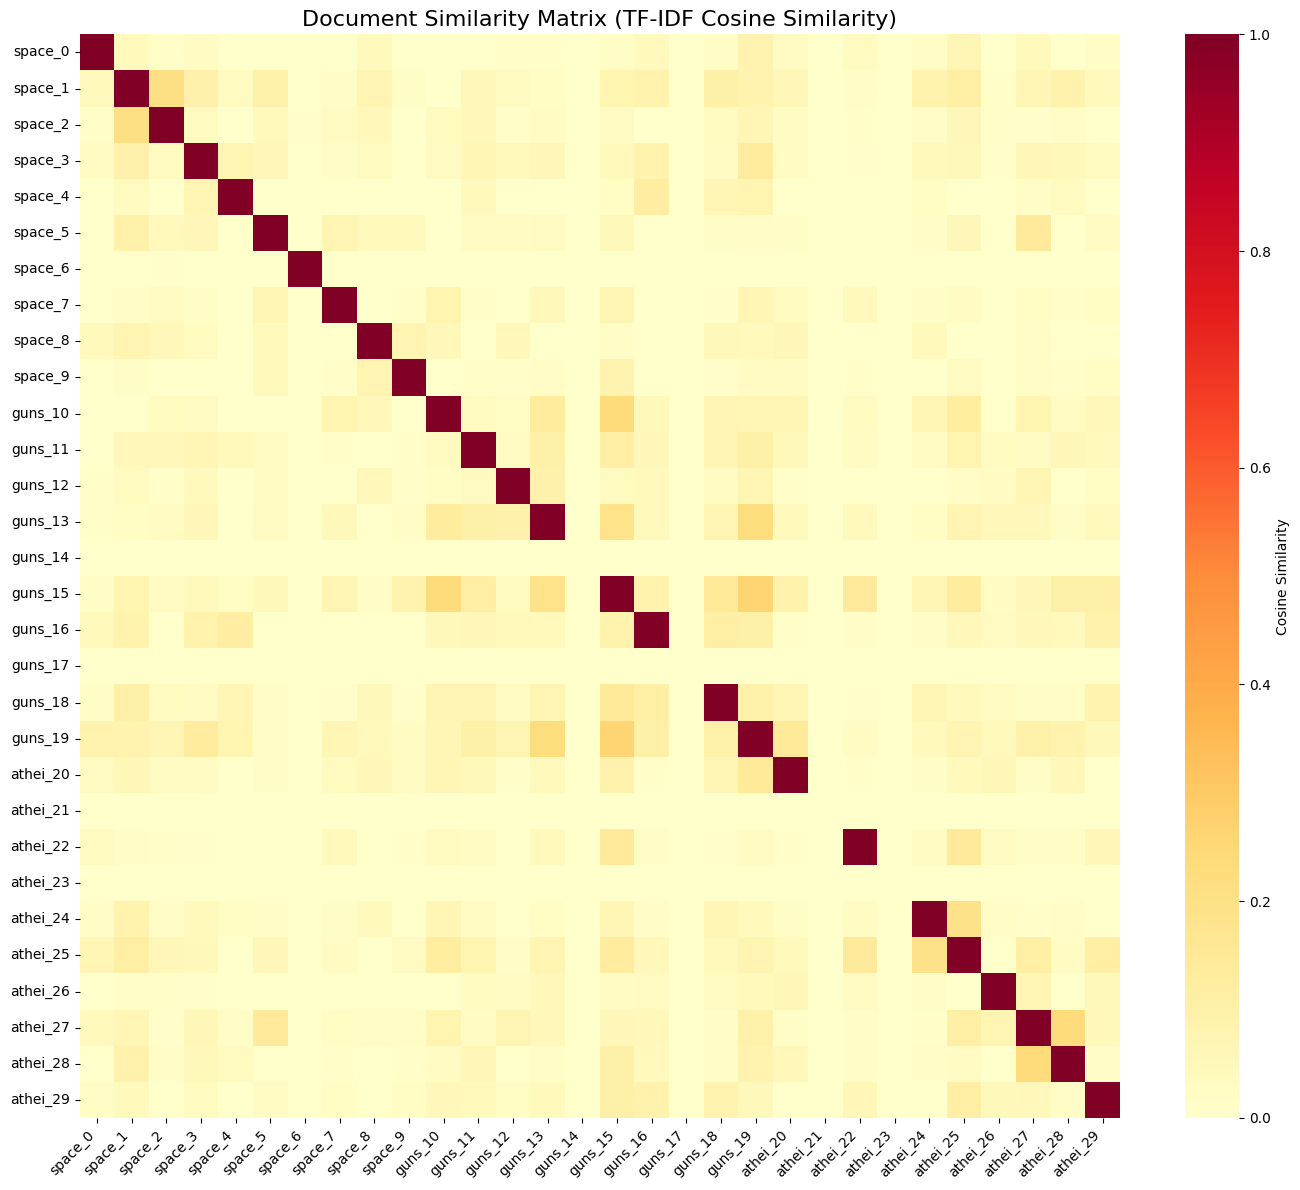

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# 1. Sample 10 documents from each of your 3 categories
sampled_dfs = []
for category in my_categories:
    # Sampling 10 docs to keep the heatmap readable (30x30 total)
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# 2. Create TF-IDF for sampled documents
# We use a smaller max_features here because the sample size is small
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# 3. Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# 4. Create labels for heatmap (Category Prefix + Sample Index)
labels = [f"{cat.split('.')[-1][:5]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# 5. Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled,
    xticklabels=labels,
    yticklabels=labels,
    mask=None, # You could use np.eye to mask the diagonal if you want
    cmap='YlOrRd', # Yellow to Orange to Red
    annot=False,
    cbar_kws={'label': 'Cosine Similarity'}
)

plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: ...

2. Most/Least similar category pairs: ...

3. Surprising similarities: ...

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
